# IDRiD Dataset 2 — Maximum-Quality Multi-Lesion Retinal Segmentation

> **Corrected dataset loader:** this notebook now uses only the official IDRiD pixel-level
> lesion-segmentation subset (**54 training originals + 27 testing originals = 81 images**).
> The 54 official training images are split into train/validation; the 27 official test
> images remain untouched until final evaluation. The notebook hard-stops if these counts
> are not found, preventing Disease Grading or Localization images from leaking into training.

## DenseNet121 Attention U-Net + Deep Supervision | MA + HE + EX + SE

This Kaggle notebook prioritizes **segmentation quality over training speed**. It trains one 4-channel model for:

- **MA** — Microaneurysms
- **HE** — Haemorrhages
- **EX** — Hard Exudates
- **SE** — Soft Exudates

### Quality-first strategy

Compared with the faster baseline, this version uses:

- **896×896 training** plus **native-resolution lesion-centered crops** so tiny MA/HE pixels are not always destroyed by whole-image downsampling.
- **Memory-efficient ImageNet DenseNet121** encoder.
- **Attention (scSE) U-Net decoder** to suppress irrelevant retinal background.
- **Deep supervision** at multiple decoder scales.
- **Rare-lesion-aware image oversampling** during training.
- Strong synchronized geometric + realistic fundus photometric augmentation.
- Weighted BCE + Dice + focal-Tversky loss for extreme pixel imbalance.
- Encoder warm-up, full fine-tuning, AdamW, gradient accumulation and clipping.
- **EMA weights** throughout training.
- Up to **150 epochs** with generous early stopping.
- Model selection using **validation threshold-tuned macro Dice**, not a fixed 0.5 threshold.
- **Top-5 checkpoint averaging**, compared against the single best EMA model.
- **4-way flip test-time augmentation (TTA)** for final threshold tuning and evaluation.
- Official test data is never used for optimization or threshold selection.

The main deployment bundle stores the final selected weights, thresholds, preprocessing and architecture metadata.


In [1]:
# ============================================================
# 1. Imports and reproducibility
# ============================================================
import os
import re
import gc
import json
import math
import random
import warnings
from copy import deepcopy
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.models import densenet121, DenseNet121_Weights

warnings.filterwarnings('ignore')

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything()

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device :', DEVICE)
if torch.cuda.is_available():
    print('GPU    :', torch.cuda.get_device_name(0))


PyTorch: 2.10.0+cu128
Device : cuda
GPU    : Tesla T4


In [2]:
# ============================================================
# 2. Maximum-quality configuration
# ============================================================
CLASS_NAMES = ['MA', 'HE', 'EX', 'SE']
CLASS_FULL_NAMES = {
    'MA': 'Microaneurysms',
    'HE': 'Haemorrhages',
    'EX': 'Hard Exudates',
    'SE': 'Soft Exudates',
}
NUM_CLASSES = len(CLASS_NAMES)

# 896 is intentionally much higher than the speed-oriented 640 baseline.
# It is a good quality/memory target for Kaggle 16-GB GPUs with batch=1 + AMP.
# If your GPU comfortably supports it, you may later try 1024.
IMG_SIZE = 896
BATCH_SIZE = 1
ACCUMULATION_STEPS = 4          # effective optimization batch ~= 4
NUM_WORKERS = 2
VAL_FRACTION = 0.20
TRAIN_SAMPLES_MULTIPLIER = 2    # weighted resampling creates more augmented views / epoch
NATIVE_PATCH_PROB = 0.45         # mix full-retina views with native-resolution lesion crops
POSITIVE_CENTER_PROB = 0.85      # native crops are usually centered near annotated lesions

MAX_EPOCHS = 150
FREEZE_ENCODER_EPOCHS = 5
ENCODER_LR = 5e-5
DECODER_LR = 2e-4
WEIGHT_DECAY = 2e-4
GRAD_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 25
LR_PATIENCE = 5
LR_FACTOR = 0.5
MIN_LR = 5e-7
EMA_DECAY = 0.999
TOPK_CHECKPOINTS = 5

AMP = torch.cuda.is_available()
PRETRAINED = True

POS_WEIGHT_MIN = 1.0
POS_WEIGHT_MAX = 35.0

# Composite loss. Tversky receives a little more weight because false negatives
# are especially important for tiny lesions.
LOSS_W_BCE = 0.25
LOSS_W_DICE = 0.35
LOSS_W_TVERSKY = 0.40
TVERSKY_ALPHA = 0.30
TVERSKY_BETA = 0.70
TVERSKY_GAMMA = 0.75
DEEP_SUPERVISION_WEIGHT = 0.30

# Model selection grid. Final thresholds are tuned again with TTA using a finer grid.
TRAIN_THRESHOLD_GRID = np.arange(0.15, 0.86, 0.05)
FINAL_THRESHOLD_GRID = np.arange(0.05, 0.951, 0.025)

OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('./outputs_max_quality')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TOPK_DIR = OUTPUT_DIR / 'idrid_topk'
TOPK_DIR.mkdir(parents=True, exist_ok=True)

BEST_CKPT = OUTPUT_DIR / 'idrid_densenet121_attention_unet_best.pth'
AVERAGED_CKPT = OUTPUT_DIR / 'idrid_densenet121_attention_unet_topk_avg.pth'
FINAL_BUNDLE = OUTPUT_DIR / 'idrid_densenet121_attention_unet_maxquality_bundle.pth'
HISTORY_CSV = OUTPUT_DIR / 'idrid_training_history_maxquality.csv'
THRESHOLD_JSON = OUTPUT_DIR / 'idrid_thresholds_maxquality.json'
TEST_METRICS_CSV = OUTPUT_DIR / 'idrid_test_metrics_maxquality.csv'

CONFIG = {
    'seed': SEED,
    'classes': CLASS_NAMES,
    'image_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'accumulation_steps': ACCUMULATION_STEPS,
    'train_samples_multiplier': TRAIN_SAMPLES_MULTIPLIER,
    'native_patch_probability': NATIVE_PATCH_PROB,
    'positive_center_probability': POSITIVE_CENTER_PROB,
    'max_epochs': MAX_EPOCHS,
    'freeze_encoder_epochs': FREEZE_ENCODER_EPOCHS,
    'encoder_lr': ENCODER_LR,
    'decoder_lr': DECODER_LR,
    'weight_decay': WEIGHT_DECAY,
    'ema_decay': EMA_DECAY,
    'topk_checkpoints': TOPK_CHECKPOINTS,
    'deep_supervision_weight': DEEP_SUPERVISION_WEIGHT,
}
print(json.dumps(CONFIG, indent=2))


{
  "seed": 42,
  "classes": [
    "MA",
    "HE",
    "EX",
    "SE"
  ],
  "image_size": 896,
  "batch_size": 1,
  "accumulation_steps": 4,
  "train_samples_multiplier": 2,
  "native_patch_probability": 0.45,
  "positive_center_probability": 0.85,
  "max_epochs": 150,
  "freeze_encoder_epochs": 5,
  "encoder_lr": 5e-05,
  "decoder_lr": 0.0002,
  "weight_decay": 0.0002,
  "ema_decay": 0.999,
  "topk_checkpoints": 5,
  "deep_supervision_weight": 0.3
}


## 3. Auto-detect Dataset 2 and pair images with masks

The code does **not** assume one exact Kaggle folder nesting. It searches for the standard IDRiD image IDs and recognizes masks by either the filename suffix (`_MA`, `_HE`, `_EX`, `_SE`) or lesion-folder names.

An absent mask for one lesion is interpreted as an **all-zero mask for that class**, while the image is still retained.

In [3]:
# ============================================================
# 3. STRICT IDRiD SEGMENTATION-ONLY dataset discovery
# ============================================================
# IMPORTANT:
# IDRiD contains several different tasks. For lesion segmentation we must use
# ONLY the official pixel-level segmentation subset:
#   54 original training images
#   27 original testing images
# Total = 81 images
#
# This cell deliberately REFUSES to continue if those counts are not found.
# It never mixes Disease Grading, Localization, or other IDRiD images.

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
ID_RE = re.compile(r'(IDRID[_-]?\d+)', re.IGNORECASE)
MASK_SUFFIX_RE = re.compile(r'_(MA|HE|EX|SE)$', re.IGNORECASE)

EXPECTED_TRAIN_IMAGES = 54
EXPECTED_TEST_IMAGES = 27
EXPECTED_TOTAL_IMAGES = 81

# Expected positive-image counts in the official IDRiD lesion-segmentation subset.
# These are used as a strong audit check after masks are read.
EXPECTED_POSITIVE_COUNTS = {
    'train_full': {'MA': 54, 'HE': 53, 'EX': 54, 'SE': 26},
    'test':       {'MA': 27, 'HE': 27, 'EX': 27, 'SE': 14},
}


def normalize_id(text):
    m = ID_RE.search(str(text))
    if not m:
        return None
    s = m.group(1).upper().replace('-', '_')
    if '_' not in s:
        s = s.replace('IDRID', 'IDRID_')
    return s


def clean_path_string(path):
    return str(path).lower().replace('\\', '/')


def lesion_class_from_path(path: Path):
    # First prefer the official filename suffix (_MA, _HE, _EX, _SE).
    m = MASK_SUFFIX_RE.search(path.stem)
    if m:
        return m.group(1).upper()

    # Fall back to the containing official lesion directory names.
    p = clean_path_string(path)
    if 'microaneur' in p:
        return 'MA'
    if 'haemorr' in p or 'hemorr' in p:
        return 'HE'
    if 'hard exud' in p:
        return 'EX'
    if 'soft exud' in p:
        return 'SE'
    return None


def is_training_path(path: Path):
    p = clean_path_string(path)
    return (
        'training set' in p
        or '/train/' in p
        or '/training/' in p
        or '/a. training set/' in p
    )


def is_testing_path(path: Path):
    p = clean_path_string(path)
    return (
        'testing set' in p
        or '/test/' in p
        or '/testing/' in p
        or '/b. testing set/' in p
    )


def locate_dataset_root():
    """
    Kaggle display names do not always match the physical /kaggle/input slug.
    Therefore, do NOT assume /kaggle/input/dataset-2 exists.

    We simply return /kaggle/input and let find_segmentation_root() identify
    the exact IDRiD segmentation subtree by its folder structure.
    """
    kaggle_input = Path('/kaggle/input')
    if not kaggle_input.exists():
        raise RuntimeError(
            "/kaggle/input was not found. This notebook is intended to run on Kaggle."
        )

    top_level = [p for p in kaggle_input.iterdir() if p.is_dir()]
    if not top_level:
        raise RuntimeError(
            "No Kaggle input dataset is attached. Click Add Input and attach Dataset 2."
        )

    print("Attached Kaggle input folders:")
    for p in top_level:
        print("  -", p)

    return kaggle_input


def find_segmentation_root(data_root: Path):
    """
    Find the exact IDRiD lesion-segmentation directory by structure, independent
    of the Kaggle dataset slug or display name.

    Expected visible structure is equivalent to:
        A. Segmentation/
            A. Segmentation/
                1. Original Images/
                2. All Segmentation Groundtruths/

    The function accepts minor naming variations but requires BOTH an
    Original Images branch and a segmentation-groundtruth branch.
    """
    candidates = []

    # Search directories only. We are not collecting images here.
    dirs = [data_root] + [p for p in data_root.rglob('*') if p.is_dir()]

    for d in dirs:
        try:
            children = [x for x in d.iterdir() if x.is_dir()]
        except Exception:
            continue

        child_names = [x.name.lower().strip() for x in children]

        has_original_direct = any(
            'original image' in name
            for name in child_names
        )
        has_gt_direct = any(
            ('segmentation ground' in name)
            or ('all segmentation ground' in name)
            or ('groundtruth' in name and 'segmentation' in name)
            or ('ground truth' in name and 'segmentation' in name)
            for name in child_names
        )

        if not (has_original_direct and has_gt_direct):
            continue

        # Strong preference for directories actually named Segmentation.
        name_lower = d.name.lower()
        path_lower = str(d).lower().replace('\\', '/')

        score = 0
        if 'segmentation' in name_lower:
            score -= 100
        if '/a. segmentation/' in path_lower or path_lower.endswith('/a. segmentation'):
            score -= 50

        # Prefer deeper/narrower structural match such as the inner A. Segmentation.
        score -= len(d.parts)

        candidates.append((score, d))

    if not candidates:
        # Print a small structural diagnostic to make path issues obvious.
        likely = []
        for d in dirs:
            if 'segmentation' in d.name.lower():
                likely.append(str(d))

        msg = (
            "Could not find the IDRiD segmentation directory containing BOTH "
            "'1. Original Images' and '2. All Segmentation Groundtruths'."
        )
        if likely:
            msg += "\nSegmentation-like directories found:\n  " + "\n  ".join(likely[:30])
        raise RuntimeError(msg)

    candidates.sort(key=lambda x: x[0])
    chosen = candidates[0][1]

    print("\nSegmentation candidates found:")
    for _, p in candidates[:10]:
        print("  -", p)

    print("\nSelected strict IDRiD segmentation root:")
    print(" ", chosen)

    return chosen

DATA_ROOT = locate_dataset_root()
SEG_ROOT = find_segmentation_root(DATA_ROOT)

# Show the exact direct child folders selected from the real Kaggle mount.
print("\nDirect contents of selected segmentation root:")
for _p in sorted([x for x in SEG_ROOT.iterdir()]):
    print("  ", _p.name)

print("Dataset root     :", DATA_ROOT)
print("Segmentation root:", SEG_ROOT)

# ---------------------------------------------------------------------
# Locate ONLY original fundus images under an "Original Images" branch.
# ---------------------------------------------------------------------
all_seg_files = [
    p for p in SEG_ROOT.rglob('*')
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
]

original_files = []
mask_files = []

for p in all_seg_files:
    pstr = clean_path_string(p)

    if 'original image' in pstr:
        original_files.append(p)
        continue

    # Ground-truth masks: require a recognizable lesion class AND a ground-truth-like path.
    lesion_class = lesion_class_from_path(p)
    if lesion_class in CLASS_NAMES and (
        'groundtruth' in pstr
        or 'ground truth' in pstr
        or 'segmentation ground' in pstr
        or 'mask' in pstr
    ):
        mask_files.append(p)


def split_original_files(files):
    train = []
    test = []
    unknown = []

    for p in files:
        if is_training_path(p):
            train.append(p)
        elif is_testing_path(p):
            test.append(p)
        else:
            unknown.append(p)

    return train, test, unknown


train_original_files, test_original_files, unknown_original_files = split_original_files(original_files)

# De-duplicate by ID and detect accidental duplicate originals.
def unique_originals_by_id(files, split_name):
    by_id = {}
    duplicates = {}

    for p in sorted(files):
        image_id = normalize_id(p.stem)
        if image_id is None:
            continue
        if image_id in by_id:
            duplicates.setdefault(image_id, [by_id[image_id]]).append(p)
        else:
            by_id[image_id] = p

    if duplicates:
        dup_text = {k: [str(x) for x in v] for k, v in duplicates.items()}
        raise RuntimeError(
            f"Duplicate original segmentation images detected in {split_name}: {dup_text}"
        )
    return by_id


train_originals = unique_originals_by_id(train_original_files, 'training')
test_originals = unique_originals_by_id(test_original_files, 'testing')

print(f"Official segmentation original images found:")
print(f"  Training: {len(train_originals)}")
print(f"  Testing : {len(test_originals)}")
print(f"  Total   : {len(train_originals) + len(test_originals)}")

# HARD SAFETY CHECK: never train on a contaminated IDRiD pool.
assert len(train_originals) == EXPECTED_TRAIN_IMAGES, (
    f"STOP: expected exactly {EXPECTED_TRAIN_IMAGES} IDRiD segmentation training originals, "
    f"but found {len(train_originals)}.\n"
    f"Segmentation root used: {SEG_ROOT}"
)
assert len(test_originals) == EXPECTED_TEST_IMAGES, (
    f"STOP: expected exactly {EXPECTED_TEST_IMAGES} IDRiD segmentation test originals, "
    f"but found {len(test_originals)}.\n"
    f"Segmentation root used: {SEG_ROOT}"
)
assert len(train_originals) + len(test_originals) == EXPECTED_TOTAL_IMAGES

if unknown_original_files:
    print(
        f"NOTE: {len(unknown_original_files)} image(s) under an Original Images branch did not "
        "contain an official train/test folder marker and were intentionally ignored."
    )

# ---------------------------------------------------------------------
# Build a strict mask map from ONLY the segmentation ground-truth subtree.
# ---------------------------------------------------------------------
mask_map = defaultdict(dict)
duplicate_masks = []

for p in sorted(mask_files):
    image_id = normalize_id(p.stem)
    lesion_class = lesion_class_from_path(p)

    if image_id is None or lesion_class not in CLASS_NAMES:
        continue

    existing = mask_map[image_id].get(lesion_class)
    if existing is not None and existing != p:
        duplicate_masks.append((image_id, lesion_class, existing, p))
    else:
        mask_map[image_id][lesion_class] = p

if duplicate_masks:
    raise RuntimeError(
        "Duplicate masks were found for the same image/class. "
        "This usually means the wrong segmentation root was selected.\n"
        + "\n".join(
            f"{iid} {cls}: {a} | {b}"
            for iid, cls, a, b in duplicate_masks[:20]
        )
    )


def make_record(image_id, img_path, split):
    masks = {c: mask_map.get(image_id, {}).get(c) for c in CLASS_NAMES}
    return {
        'id': image_id,
        'image': img_path,
        'masks': masks,
        'split': split,
        'has_any_mask': any(v is not None for v in masks.values()),
    }


records = []
records.extend(
    make_record(image_id, img_path, 'train')
    for image_id, img_path in sorted(train_originals.items())
)
records.extend(
    make_record(image_id, img_path, 'test')
    for image_id, img_path in sorted(test_originals.items())
)

assert len(records) == EXPECTED_TOTAL_IMAGES
assert len({r['id'] for r in records}) == EXPECTED_TOTAL_IMAGES, (
    "Duplicate IDs exist between official training and testing sets."
)

# Every official segmentation image should have at least one annotated lesion mask.
without_any_mask = [r['id'] for r in records if not r['has_any_mask']]
assert not without_any_mask, (
    "STOP: official segmentation images were found without any corresponding lesion masks: "
    f"{without_any_mask[:20]}. Check the mask-folder discovery."
)

# Compact audit table.
audit_rows = []
for r in records:
    audit_rows.append({
        'id': r['id'],
        'official_split': r['split'],
        'image': str(r['image']),
        **{f'{c}_mask_found': r['masks'][c] is not None for c in CLASS_NAMES},
    })

audit_df = pd.DataFrame(audit_rows)

print("\nStrict segmentation-only discovery: PASSED")
print("No Disease Grading / Localization images can enter this records list.")
display(audit_df.groupby('official_split')[[f'{c}_mask_found' for c in CLASS_NAMES]].sum())
display(audit_df.head(10))


Attached Kaggle input folders:
  - /kaggle/input/datasets

Segmentation candidates found:
  - /kaggle/input/datasets/yashraneja/dataset-2/Dataset 2/A. Segmentation/A. Segmentation

Selected strict IDRiD segmentation root:
  /kaggle/input/datasets/yashraneja/dataset-2/Dataset 2/A. Segmentation/A. Segmentation

Direct contents of selected segmentation root:
   1. Original Images
   2. All Segmentation Groundtruths
   CC-BY-4.0.txt
   LICENSE.txt
Dataset root     : /kaggle/input
Segmentation root: /kaggle/input/datasets/yashraneja/dataset-2/Dataset 2/A. Segmentation/A. Segmentation
Official segmentation original images found:
  Training: 54
  Testing : 27
  Total   : 81

Strict segmentation-only discovery: PASSED
No Disease Grading / Localization images can enter this records list.


,MA_mask_found,HE_mask_found,EX_mask_found,SE_mask_found
official_split,,,,
test,27,27,27,14
train,54,53,54,26


,id,official_split,image,MA_mask_found,HE_mask_found,EX_mask_found,SE_mask_found
0,IDRID_01,train,/kaggle/input/datasets/yashraneja/dataset-2/Da...,True,True,True,False
1,IDRID_02,train,/kaggle/input/datasets/yashraneja/dataset-2/Da...,True,True,True,False
2,IDRID_03,train,/kaggle/input/datasets/yashraneja/dataset-2/Da...,True,True,True,True
3,IDRID_04,train,/kaggle/input/datasets/yashraneja/dataset-2/Da...,True,True,True,False
4,IDRID_05,train,/kaggle/input/datasets/yashraneja/dataset-2/Da...,True,True,True,False
5,IDRID_06,train,/kaggle/input/datasets/yashraneja/dataset-2/Da...,True,True,True,False
6,IDRID_07,train,/kaggle/input/datasets/yashraneja/dataset-2/Da...,True,True,True,False
7,IDRID_08,train,/kaggle/input/datasets/yashraneja/dataset-2/Da...,True,True,True,True
8,IDRID_09,train,/kaggle/input/datasets/yashraneja/dataset-2/Da...,True,True,True,False
9,IDRID_10,train,/kaggle/input/datasets/yashraneja/dataset-2/Da...,True,True,True,False


In [4]:
# ============================================================
# 4. Verify masks and lesion presence
# ============================================================
def read_binary_mask(path):
    if path is None:
        return None
    m = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise RuntimeError(f'Could not read mask: {path}')
    return (m > 0).astype(np.uint8)


def lesion_presence(record):
    present = []
    for c in CLASS_NAMES:
        p = record['masks'][c]
        if p is None:
            present.append(0)
        else:
            m = read_binary_mask(p)
            present.append(int(m.any()))
    return np.array(present, dtype=np.int64)


# Cache true lesion presence once.
for r in records:
    r['presence'] = lesion_presence(r)

presence_df = pd.DataFrame(
    [r['presence'] for r in records],
    columns=CLASS_NAMES,
    index=[r['id'] for r in records]
)

official_train_records = [r for r in records if r['split'] == 'train']
official_test_records = [r for r in records if r['split'] == 'test']

train_pos = np.stack([r['presence'] for r in official_train_records]).sum(axis=0)
test_pos = np.stack([r['presence'] for r in official_test_records]).sum(axis=0)

train_pos_dict = dict(zip(CLASS_NAMES, train_pos.tolist()))
test_pos_dict = dict(zip(CLASS_NAMES, test_pos.tolist()))

print("Official 54-image training-set lesion-positive counts:", train_pos_dict)
print("Official 27-image testing-set lesion-positive counts :", test_pos_dict)

# Strong audit against the standard IDRiD segmentation subset.
assert train_pos_dict == EXPECTED_POSITIVE_COUNTS['train_full'], (
    "STOP: lesion-positive counts in the 54-image training subset do not match "
    f"the expected IDRiD segmentation data.\nExpected: {EXPECTED_POSITIVE_COUNTS['train_full']}\n"
    f"Found:    {train_pos_dict}"
)
assert test_pos_dict == EXPECTED_POSITIVE_COUNTS['test'], (
    "STOP: lesion-positive counts in the 27-image test subset do not match "
    f"the expected IDRiD segmentation data.\nExpected: {EXPECTED_POSITIVE_COUNTS['test']}\n"
    f"Found:    {test_pos_dict}"
)

print("Mask/presence audit: PASSED")


Official 54-image training-set lesion-positive counts: {'MA': 54, 'HE': 53, 'EX': 54, 'SE': 26}
Official 27-image testing-set lesion-positive counts : {'MA': 27, 'HE': 27, 'EX': 27, 'SE': 14}
Mask/presence audit: PASSED


In [5]:
# ============================================================
# 5. Leakage-safe split: ONLY the 54 official training images
# ============================================================
def split_objective(P, val_idx, target_val_count, target_pos):
    """Score how well a candidate validation split matches lesion prevalence."""
    val_idx = np.asarray(val_idx, dtype=int)
    val_pos = P[val_idx].sum(axis=0)

    # Relative class-count error; rare SE receives equal class-level importance.
    denom = np.maximum(target_pos, 1.0)
    class_error = np.mean(np.abs(val_pos - target_pos) / denom)

    # Penalize any lesion class disappearing from validation.
    missing_penalty = float(np.sum((target_pos > 0) & (val_pos == 0))) * 5.0

    # Exact size is already enforced, but retain a defensive size term.
    size_error = abs(len(val_idx) - target_val_count) / max(target_val_count, 1)

    return class_error + missing_penalty + size_error


def balanced_multilabel_split(records_in, val_fraction=0.2, seed=42, trials=20000):
    """
    Multi-start deterministic search for a small multilabel validation split.

    With only 54 images, we can cheaply examine many candidate 11-image subsets.
    We choose the subset whose MA/HE/EX/SE prevalence most closely matches the
    full 54-image official training set while keeping every lesion represented.
    """
    n = len(records_in)
    assert n == EXPECTED_TRAIN_IMAGES, (
        f"This splitter must receive exactly the 54 official segmentation training images; got {n}."
    )

    n_val = max(1, int(round(n * val_fraction)))   # 11 for 20%
    P = np.stack([r['presence'] for r in records_in]).astype(np.int64)
    total_pos = P.sum(axis=0).astype(np.float64)
    target_pos = total_pos * (n_val / n)

    rng = np.random.default_rng(seed)

    best_idx = None
    best_score = np.inf

    # First include a deterministic greedy candidate that strongly covers rare classes.
    rarity = 1.0 / np.maximum(total_pos, 1.0)
    selected = []
    remaining = list(range(n))

    while len(selected) < n_val:
        current = P[selected].sum(axis=0) if selected else np.zeros(NUM_CLASSES, dtype=int)
        deficits = np.maximum(target_pos - current, 0.0)

        scored = []
        for idx in remaining:
            p = P[idx]
            benefit = float(np.sum(deficits * p * rarity))
            diversity = float(np.sum(p * rarity))
            scored.append((benefit, diversity, -idx, idx))
        scored.sort(reverse=True)
        chosen = scored[0][-1]
        selected.append(chosen)
        remaining.remove(chosen)

    best_idx = np.array(sorted(selected), dtype=int)
    best_score = split_objective(P, best_idx, n_val, target_pos)

    # Random multi-start search substantially improves balance for such a tiny dataset.
    for _ in range(trials):
        cand = np.sort(rng.choice(n, size=n_val, replace=False))
        score = split_objective(P, cand, n_val, target_pos)

        if score < best_score - 1e-12:
            best_score = score
            best_idx = cand

    val_set = set(best_idx.tolist())
    train_part = [r for i, r in enumerate(records_in) if i not in val_set]
    val_part = [r for i, r in enumerate(records_in) if i in val_set]

    assert len(train_part) + len(val_part) == EXPECTED_TRAIN_IMAGES
    assert len(val_part) == n_val
    return train_part, val_part


official_train = [r for r in records if r['split'] == 'train']
official_test = [r for r in records if r['split'] == 'test']

# HARD CHECKS — no fallback to unrelated IDRiD branches.
assert len(official_train) == EXPECTED_TRAIN_IMAGES
assert len(official_test) == EXPECTED_TEST_IMAGES

train_records, val_records = balanced_multilabel_split(
    official_train,
    val_fraction=VAL_FRACTION,
    seed=SEED,
)
test_records = official_test


def split_summary(name, recs):
    if not recs:
        print(f'{name:>10}: 0')
        return
    P = np.stack([r['presence'] for r in recs])
    print(
        f'{name:>10}: {len(recs):2d} | positives:',
        dict(zip(CLASS_NAMES, P.sum(axis=0).tolist()))
    )


print("FINAL SEGMENTATION-ONLY SPLIT")
split_summary('Train', train_records)
split_summary('Val', val_records)
split_summary('Test', test_records)

print(
    f"\nExpected image counts: Train={EXPECTED_TRAIN_IMAGES - int(round(EXPECTED_TRAIN_IMAGES * VAL_FRACTION))}, "
    f"Val={int(round(EXPECTED_TRAIN_IMAGES * VAL_FRACTION))}, "
    f"Test={EXPECTED_TEST_IMAGES}"
)

# Leakage checks
train_ids = {r['id'] for r in train_records}
val_ids = {r['id'] for r in val_records}
test_ids = {r['id'] for r in test_records}

assert len(train_ids) == len(train_records)
assert len(val_ids) == len(val_records)
assert len(test_ids) == len(test_records)

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

# Confirm the training+validation pool exactly reconstructs the official 54-image set.
assert train_ids | val_ids == {r['id'] for r in official_train}

print("Leakage check: PASSED")
print("Official 54-image training pool integrity: PASSED")
print("Official 27-image test set remains untouched: PASSED")


FINAL SEGMENTATION-ONLY SPLIT
     Train: 43 | positives: {'MA': 43, 'HE': 42, 'EX': 43, 'SE': 21}
       Val: 11 | positives: {'MA': 11, 'HE': 11, 'EX': 11, 'SE': 5}
      Test: 27 | positives: {'MA': 27, 'HE': 27, 'EX': 27, 'SE': 14}

Expected image counts: Train=43, Val=11, Test=27
Leakage check: PASSED
Official 54-image training pool integrity: PASSED
Official 27-image test set remains untouched: PASSED


## 6. High-resolution preprocessing and augmentation

The retinal field is cropped from the black outer border. Training deliberately mixes **whole-retina 896×896 views** with **native-resolution 896×896 lesion-centered crops**. This gives the network global retinal context while also showing tiny microaneurysms and haemorrhages without always shrinking the original 4K-scale image. Geometric augmentation is synchronized between image and masks. Photometric augmentation affects only the image and includes illumination, gamma, CLAHE, mild color, blur/sharpen and sensor-noise variation.

The goal is to expose the model to realistic camera/field variability without corrupting lesion labels.


In [6]:
# ============================================================
# 6. High-resolution preprocessing / augmentation helpers
# ============================================================
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def crop_retinal_field(image, masks=None, threshold=8, margin=12):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    ys, xs = np.where(gray > threshold)
    if len(xs) < 100 or len(ys) < 100:
        return image, masks

    x0 = max(int(xs.min()) - margin, 0)
    x1 = min(int(xs.max()) + margin + 1, image.shape[1])
    y0 = max(int(ys.min()) - margin, 0)
    y1 = min(int(ys.max()) + margin + 1, image.shape[0])

    image = image[y0:y1, x0:x1]
    if masks is not None:
        masks = masks[:, y0:y1, x0:x1]
    return image, masks


def resize_and_pad(image, masks, size):
    h, w = image.shape[:2]
    scale = min(size / h, size / w)
    nh, nw = int(round(h * scale)), int(round(w * scale))

    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    image_r = cv2.resize(image, (nw, nh), interpolation=interp)
    masks_r = np.stack([
        cv2.resize(m, (nw, nh), interpolation=cv2.INTER_NEAREST)
        for m in masks
    ], axis=0)

    top = (size - nh) // 2
    bottom = size - nh - top
    left = (size - nw) // 2
    right = size - nw - left

    image_p = cv2.copyMakeBorder(image_r, top, bottom, left, right,
                                 cv2.BORDER_CONSTANT, value=(0, 0, 0))
    masks_p = np.pad(masks_r, ((0, 0), (top, bottom), (left, right)),
                     mode='constant', constant_values=0)
    return image_p, masks_p



def lesion_aware_native_crop(image, masks, size):
    """Return a native-resolution square crop, usually centered near a lesion.

    MA/HE/SE receive modest extra sampling priority because they are generally
    harder/sparser than EX. If the image is smaller than the requested crop,
    it falls back to aspect-preserving resize+pad.
    """
    h, w = image.shape[:2]
    if h < size or w < size:
        return resize_and_pad(image, masks, size)

    present = [ci for ci in range(NUM_CLASSES) if masks[ci].any()]
    center_on_positive = bool(present) and random.random() < POSITIVE_CENTER_PROB

    if center_on_positive:
        # Fixed priorities: MA > HE/SE > EX. They only operate among classes
        # actually present in the current image.
        priority = np.array([3.0, 2.0, 1.0, 2.0], dtype=np.float64)
        probs = priority[present]
        probs = probs / probs.sum()
        ci = int(np.random.choice(present, p=probs))
        ys, xs = np.where(masks[ci] > 0)
        k = np.random.randint(len(xs))
        cx, cy = int(xs[k]), int(ys[k])
        # Jitter prevents the lesion from always appearing dead-center.
        cx += int(random.uniform(-0.18, 0.18) * size)
        cy += int(random.uniform(-0.18, 0.18) * size)
    else:
        cx = random.randint(size // 2, max(size // 2, w - size // 2))
        cy = random.randint(size // 2, max(size // 2, h - size // 2))

    x0 = int(np.clip(cx - size // 2, 0, w - size))
    y0 = int(np.clip(cy - size // 2, 0, h - size))
    x1, y1 = x0 + size, y0 + size
    return image[y0:y1, x0:x1], masks[:, y0:y1, x0:x1]

def apply_affine(image, masks):
    h, w = image.shape[:2]
    angle = random.uniform(-25.0, 25.0)
    scale = random.uniform(0.92, 1.08)
    tx = random.uniform(-0.04, 0.04) * w
    ty = random.uniform(-0.04, 0.04) * h
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    M[0, 2] += tx
    M[1, 2] += ty

    image = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR,
                           borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))
    masks = np.stack([
        cv2.warpAffine(m, M, (w, h), flags=cv2.INTER_NEAREST,
                       borderMode=cv2.BORDER_CONSTANT, borderValue=0)
        for m in masks
    ], axis=0)
    return image, masks


def random_clahe_rgb(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=random.uniform(1.3, 2.2), tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2RGB)


def random_color_jitter(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[..., 0] = (hsv[..., 0] + random.uniform(-3, 3)) % 180
    hsv[..., 1] *= random.uniform(0.90, 1.10)
    hsv[..., 2] *= random.uniform(0.90, 1.10)
    hsv = np.clip(hsv, 0, 255).astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)


def augment_joint(image, masks):
    if random.random() < 0.5:
        image = np.ascontiguousarray(image[:, ::-1])
        masks = np.ascontiguousarray(masks[:, :, ::-1])

    if random.random() < 0.35:
        image = np.ascontiguousarray(image[::-1, :])
        masks = np.ascontiguousarray(masks[:, ::-1, :])

    if random.random() < 0.75:
        image, masks = apply_affine(image, masks)

    if random.random() < 0.60:
        alpha = random.uniform(0.82, 1.18)
        beta = random.uniform(-15, 15)
        image = np.clip(image.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

    if random.random() < 0.40:
        gamma = random.uniform(0.80, 1.25)
        lut = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype('uint8')
        image = cv2.LUT(image, lut)

    if random.random() < 0.25:
        image = random_clahe_rgb(image)

    if random.random() < 0.25:
        image = random_color_jitter(image)

    r = random.random()
    if r < 0.10:
        image = cv2.GaussianBlur(image, (3, 3), 0)
    elif r < 0.20:
        blur = cv2.GaussianBlur(image, (0, 0), 1.0)
        image = cv2.addWeighted(image, 1.35, blur, -0.35, 0)

    if random.random() < 0.20:
        noise = np.random.normal(0, random.uniform(1.0, 5.0), image.shape).astype(np.float32)
        image = np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    return image, masks


def normalize_image(image):
    x = image.astype(np.float32) / 255.0
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    x = np.transpose(x, (2, 0, 1))
    return x.astype(np.float32)


In [7]:
# ============================================================
# 7. Dataset and rare-lesion-aware DataLoaders
# ============================================================
class IDRiDSegmentationDataset(Dataset):
    def __init__(self, records, image_size=896, train=False):
        self.records = records
        self.image_size = image_size
        self.train = train

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        bgr = cv2.imread(str(r['image']), cv2.IMREAD_COLOR)
        if bgr is None:
            raise RuntimeError(f"Could not read image: {r['image']}")
        image = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

        h, w = image.shape[:2]
        mask_list = []
        for c in CLASS_NAMES:
            p = r['masks'][c]
            if p is None:
                m = np.zeros((h, w), dtype=np.uint8)
            else:
                m = read_binary_mask(p)
                if m.shape != (h, w):
                    m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
            mask_list.append(m)
        masks = np.stack(mask_list, axis=0).astype(np.uint8)

        image, masks = crop_retinal_field(image, masks)

        # Quality-first mixed-scale training:
        # some samples retain native lesion detail; others preserve global retina context.
        if self.train and random.random() < NATIVE_PATCH_PROB:
            image, masks = lesion_aware_native_crop(image, masks, self.image_size)
        else:
            image, masks = resize_and_pad(image, masks, self.image_size)

        if self.train:
            image, masks = augment_joint(image, masks)

        image = normalize_image(image)
        masks = (masks > 0).astype(np.float32)

        return {
            'image': torch.from_numpy(image),
            'mask': torch.from_numpy(masks),
            'id': r['id'],
        }


def make_train_sampler(records_in):
    P = np.stack([r['presence'] for r in records_in]).astype(np.float64)
    class_freq = np.maximum(P.mean(axis=0), 1e-3)
    rarity_bonus = 1.0 / np.sqrt(class_freq)
    weights = 1.0 + (P * rarity_bonus[None, :]).sum(axis=1)
    weights = weights / weights.mean()
    print('Sampling class frequencies:', dict(zip(CLASS_NAMES, np.round(class_freq, 3))))
    print('Sampling weight range:', float(weights.min()), 'to', float(weights.max()))
    return WeightedRandomSampler(
        weights=torch.as_tensor(weights, dtype=torch.double),
        num_samples=max(len(records_in), len(records_in) * TRAIN_SAMPLES_MULTIPLIER),
        replacement=True,
    )


train_ds = IDRiDSegmentationDataset(train_records, IMG_SIZE, train=True)
val_ds = IDRiDSegmentationDataset(val_records, IMG_SIZE, train=False)
test_ds = IDRiDSegmentationDataset(test_records, IMG_SIZE, train=False) if test_records else None

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
if NUM_WORKERS > 0:
    loader_kwargs.update(dict(persistent_workers=True, prefetch_factor=2))

train_sampler = make_train_sampler(train_records)
train_loader = DataLoader(train_ds, sampler=train_sampler, drop_last=False, **loader_kwargs)
val_loader = DataLoader(val_ds, shuffle=False, drop_last=False, **loader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, drop_last=False, **loader_kwargs) if test_ds is not None else None

batch = next(iter(train_loader))
print('Image batch:', tuple(batch['image'].shape))
print('Mask batch :', tuple(batch['mask'].shape))
print('IDs        :', batch['id'])


Sampling class frequencies: {'MA': np.float64(1.0), 'HE': np.float64(0.977), 'EX': np.float64(1.0), 'SE': np.float64(0.488)}
Sampling weight range: 0.6400491649072012 to 1.1612166927490482
Image batch: (1, 3, 896, 896)
Mask batch : (1, 4, 896, 896)
IDs        : ['IDRID_03']


In [8]:
# ============================================================
# 8. Estimate pixel imbalance from TRAINING data only
# ============================================================
def estimate_pos_weights(records_in, stat_size=256):
    positives = np.zeros(NUM_CLASSES, dtype=np.float64)
    totals = np.zeros(NUM_CLASSES, dtype=np.float64)

    for r in records_in:
        # Use the original image only to establish shape when a class mask is absent.
        img = cv2.imread(str(r['image']), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        h, w = img.shape[:2]

        for ci, c in enumerate(CLASS_NAMES):
            p = r['masks'][c]
            if p is None:
                small = np.zeros((stat_size, stat_size), dtype=np.uint8)
            else:
                m = read_binary_mask(p)
                if m.shape != (h, w):
                    m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
                small = cv2.resize(m, (stat_size, stat_size), interpolation=cv2.INTER_NEAREST)

            positives[ci] += float((small > 0).sum())
            totals[ci] += float(small.size)

    negatives = totals - positives
    raw = (negatives + 1.0) / (positives + 1.0)
    clipped = np.clip(raw, POS_WEIGHT_MIN, POS_WEIGHT_MAX)
    prevalence = positives / np.maximum(totals, 1)
    return prevalence, raw, clipped

prevalence, raw_pos_weight, clipped_pos_weight = estimate_pos_weights(train_records)
imbalance_df = pd.DataFrame({
    'class': CLASS_NAMES,
    'name': [CLASS_FULL_NAMES[c] for c in CLASS_NAMES],
    'pixel_prevalence_est': prevalence,
    'raw_pos_weight': raw_pos_weight,
    'used_pos_weight': clipped_pos_weight,
})
display(imbalance_df)

POS_WEIGHT = torch.tensor(clipped_pos_weight, dtype=torch.float32, device=DEVICE).view(1, NUM_CLASSES, 1, 1)

,class,name,pixel_prevalence_est,raw_pos_weight,used_pos_weight
0,MA,Microaneurysms,0.001079,925.076241,35.0
1,HE,Haemorrhages,0.009747,101.593927,35.0
2,EX,Hard Exudates,0.009427,105.069332,35.0
3,SE,Soft Exudates,0.001809,551.775598,35.0


## 9. DenseNet121 Attention U-Net with deep supervision

The encoder uses **memory-efficient DenseNet121**, enabling higher-resolution training. The decoder adds **concurrent spatial-and-channel squeeze/excitation (scSE)** after each U-Net fusion block. Three auxiliary segmentation heads provide deep supervision during training; only the final full-resolution head is used for deployment.


In [9]:
# ============================================================
# 9. DenseNet121 Attention U-Net + deep supervision
# ============================================================
def make_group_norm(channels):
    for groups in (16, 8, 4, 2, 1):
        if channels % groups == 0:
            return nn.GroupNorm(groups, channels)
    return nn.GroupNorm(1, channels)


class SCSE(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.cse = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, hidden, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1),
            nn.Sigmoid(),
        )
        self.sse = nn.Sequential(
            nn.Conv2d(channels, 1, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.cse(x) + x * self.sse(x)


class ConvGNAct(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            make_group_norm(out_ch),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            make_group_norm(out_ch),
            nn.SiLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UpAttentionBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.0):
        super().__init__()
        self.conv = ConvGNAct(in_ch + skip_ch, out_ch, dropout=dropout)
        self.attn = SCSE(out_ch)

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.attn(self.conv(x))


class DenseNet121AttentionUNet(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super().__init__()
        weights = DenseNet121_Weights.DEFAULT if pretrained else None
        try:
            backbone = densenet121(weights=weights, memory_efficient=True)
            if pretrained:
                print('Loaded ImageNet-pretrained memory-efficient DenseNet121 encoder.')
        except Exception as e:
            print('WARNING: pretrained weights could not be loaded:', e)
            print('Falling back to randomly initialized DenseNet121.')
            backbone = densenet121(weights=None, memory_efficient=True)

        f = backbone.features
        self.enc0 = nn.Sequential(f.conv0, f.norm0, f.relu0)   # 64, /2
        self.pool0 = f.pool0                                  # /4
        self.enc1 = f.denseblock1                             # 256, /4
        self.tr1 = f.transition1                              # 128, /8
        self.enc2 = f.denseblock2                             # 512, /8
        self.tr2 = f.transition2                              # 256, /16
        self.enc3 = f.denseblock3                             # 1024, /16
        self.tr3 = f.transition3                              # 512, /32
        self.enc4 = f.denseblock4                             # 1024, /32
        self.norm5 = f.norm5

        self.up3 = UpAttentionBlock(1024, 1024, 512, dropout=0.15)
        self.up2 = UpAttentionBlock(512, 512, 256, dropout=0.10)
        self.up1 = UpAttentionBlock(256, 256, 128, dropout=0.08)
        self.up0 = UpAttentionBlock(128, 64, 64, dropout=0.05)
        self.final_conv = ConvGNAct(64, 32, dropout=0.0)
        self.head = nn.Conv2d(32, num_classes, 1)

        # Auxiliary heads for deep supervision.
        self.aux2 = nn.Conv2d(256, num_classes, 1)
        self.aux1 = nn.Conv2d(128, num_classes, 1)
        self.aux0 = nn.Conv2d(64, num_classes, 1)

    def forward(self, x, return_aux=False):
        input_hw = x.shape[-2:]
        s0 = self.enc0(x)
        x = self.pool0(s0)
        s1 = self.enc1(x)
        x = self.tr1(s1)
        s2 = self.enc2(x)
        x = self.tr2(s2)
        s3 = self.enc3(x)
        x = self.tr3(s3)
        x = F.silu(self.norm5(self.enc4(x)), inplace=True)

        x3 = self.up3(x, s3)
        x2 = self.up2(x3, s2)
        x1 = self.up1(x2, s1)
        x0 = self.up0(x1, s0)

        main = F.interpolate(x0, size=input_hw, mode='bilinear', align_corners=False)
        main = self.head(self.final_conv(main))

        if not return_aux:
            return main

        aux = [
            F.interpolate(self.aux2(x2), size=input_hw, mode='bilinear', align_corners=False),
            F.interpolate(self.aux1(x1), size=input_hw, mode='bilinear', align_corners=False),
            F.interpolate(self.aux0(x0), size=input_hw, mode='bilinear', align_corners=False),
        ]
        return main, aux

    def encoder_parameters(self):
        modules = [self.enc0, self.pool0, self.enc1, self.tr1, self.enc2, self.tr2,
                   self.enc3, self.tr3, self.enc4, self.norm5]
        for module in modules:
            yield from module.parameters()

    def decoder_parameters(self):
        modules = [self.up3, self.up2, self.up1, self.up0, self.final_conv,
                   self.head, self.aux2, self.aux1, self.aux0]
        for module in modules:
            yield from module.parameters()

    def set_encoder_trainable(self, trainable=True):
        for p in self.encoder_parameters():
            p.requires_grad = trainable

    def freeze_encoder_batchnorm(self):
        modules = [self.enc0, self.enc1, self.tr1, self.enc2, self.tr2,
                   self.enc3, self.tr3, self.enc4, self.norm5]
        for module in modules:
            for m in module.modules():
                if isinstance(m, nn.BatchNorm2d):
                    m.eval()
                    for p in m.parameters():
                        p.requires_grad = False


model = DenseNet121AttentionUNet(NUM_CLASSES, pretrained=PRETRAINED).to(DEVICE)
model.set_encoder_trainable(False)
model.freeze_encoder_batchnorm()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total/1e6:.2f}M total | {trainable/1e6:.2f}M initially trainable')

with torch.no_grad():
    dummy = torch.randn(1, 3, 128, 128, device=DEVICE)
    main, aux = model(dummy, return_aux=True)
print('Main output:', tuple(main.shape), '| Aux:', [tuple(a.shape) for a in aux])
del dummy, main, aux
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 240MB/s]


Loaded ImageNet-pretrained memory-efficient DenseNet121 encoder.
Parameters: 22.66M total | 15.71M initially trainable
Main output: (1, 4, 128, 128) | Aux: [(1, 4, 128, 128), (1, 4, 128, 128), (1, 4, 128, 128)]


In [10]:
# ============================================================
# 10. Composite imbalance-aware loss + deep supervision
# ============================================================
class CompositeSegmentationLoss(nn.Module):
    def __init__(self, pos_weight):
        super().__init__()
        self.register_buffer('pos_weight', pos_weight.clone().detach())

    def base_loss(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='mean'
        )

        probs = torch.sigmoid(logits)
        dims = (0, 2, 3)
        smooth = 1.0

        intersection = (probs * targets).sum(dims)
        denominator = probs.sum(dims) + targets.sum(dims)
        dice = (2.0 * intersection + smooth) / (denominator + smooth)
        dice_loss = (1.0 - dice).mean()

        tp = (probs * targets).sum(dims)
        fp = (probs * (1.0 - targets)).sum(dims)
        fn = ((1.0 - probs) * targets).sum(dims)
        tversky = (tp + smooth) / (
            tp + TVERSKY_ALPHA * fp + TVERSKY_BETA * fn + smooth
        )
        focal_tversky = torch.pow(1.0 - tversky, TVERSKY_GAMMA).mean()

        total = (
            LOSS_W_BCE * bce +
            LOSS_W_DICE * dice_loss +
            LOSS_W_TVERSKY * focal_tversky
        )
        return total, bce, dice_loss, focal_tversky

    def forward(self, logits, targets, aux_logits=None):
        total, bce, dice_loss, focal_tversky = self.base_loss(logits, targets)

        if aux_logits:
            aux_losses = [self.base_loss(a, targets)[0] for a in aux_logits]
            aux_mean = torch.stack(aux_losses).mean()
            total = total + DEEP_SUPERVISION_WEIGHT * aux_mean
        else:
            aux_mean = torch.zeros((), device=logits.device)

        return total, {
            'bce': float(bce.detach()),
            'dice_loss': float(dice_loss.detach()),
            'focal_tversky': float(focal_tversky.detach()),
            'aux_loss': float(aux_mean.detach()),
        }

criterion = CompositeSegmentationLoss(POS_WEIGHT).to(DEVICE)


In [11]:
# ============================================================
# 11. Metrics, TTA, EMA, optimizer, scheduler, scaler
# ============================================================
@torch.no_grad()
def segmentation_stats_from_probs(probs, targets, thresholds=0.5):
    if np.isscalar(thresholds):
        th = torch.full((1, NUM_CLASSES, 1, 1), float(thresholds), device=probs.device)
    else:
        th = torch.as_tensor(thresholds, dtype=probs.dtype, device=probs.device).view(1, NUM_CLASSES, 1, 1)

    pred = probs >= th
    true = targets >= 0.5
    dims = (0, 2, 3)
    tp = (pred & true).sum(dims).double().cpu().numpy()
    fp = (pred & ~true).sum(dims).double().cpu().numpy()
    fn = (~pred & true).sum(dims).double().cpu().numpy()
    tn = (~pred & ~true).sum(dims).double().cpu().numpy()
    return tp, fp, fn, tn


def metrics_from_stats(tp, fp, fn, tn):
    eps = 1e-9
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    sensitivity = (tp + eps) / (tp + fn + eps)
    specificity = (tn + eps) / (tn + fp + eps)
    precision = (tp + eps) / (tp + fp + eps)
    return {
        'dice': dice,
        'iou': iou,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
    }


@torch.no_grad()
def predict_probs(model_eval, images, tta=False):
    if not tta:
        return torch.sigmoid(model_eval(images))

    probs = []
    # identity
    probs.append(torch.sigmoid(model_eval(images)))
    # horizontal flip
    x = torch.flip(images, dims=[3])
    p = torch.sigmoid(model_eval(x))
    probs.append(torch.flip(p, dims=[3]))
    # vertical flip
    x = torch.flip(images, dims=[2])
    p = torch.sigmoid(model_eval(x))
    probs.append(torch.flip(p, dims=[2]))
    # horizontal + vertical
    x = torch.flip(images, dims=[2, 3])
    p = torch.sigmoid(model_eval(x))
    probs.append(torch.flip(p, dims=[2, 3]))
    return torch.stack(probs, dim=0).mean(dim=0)


class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.ema = deepcopy(model).eval()
        self.decay = decay
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        ema_state = self.ema.state_dict()
        model_state = model.state_dict()
        for k, ema_v in ema_state.items():
            model_v = model_state[k].detach()
            if torch.is_floating_point(ema_v):
                ema_v.mul_(self.decay).add_(model_v, alpha=1.0 - self.decay)
            else:
                ema_v.copy_(model_v)


encoder_params = list(model.encoder_parameters())
decoder_params = list(model.decoder_parameters())
optimizer = torch.optim.AdamW([
    {'params': encoder_params, 'lr': ENCODER_LR},
    {'params': decoder_params, 'lr': DECODER_LR},
], weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=LR_FACTOR,
    patience=LR_PATIENCE, min_lr=MIN_LR
)

scaler = torch.cuda.amp.GradScaler(enabled=AMP)
ema = ModelEMA(model, EMA_DECAY)

print('AdamW, ReduceLROnPlateau, AMP, EMA and 4-way TTA functions ready.')


AdamW, ReduceLROnPlateau, AMP, EMA and 4-way TTA functions ready.


In [12]:
# ============================================================
# 12. Training / validation / threshold-grid functions
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, scaler, ema):
    model.train()
    model.freeze_encoder_batchnorm()

    running_loss = 0.0
    seen = 0
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(loader):
        images = batch['image'].to(DEVICE, non_blocking=True)
        masks = batch['mask'].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=AMP):
            logits, aux_logits = model(images, return_aux=True)
            loss, _ = criterion(logits, masks, aux_logits=aux_logits)
            loss_to_backward = loss / ACCUMULATION_STEPS

        scaler.scale(loss_to_backward).backward()

        should_step = ((step + 1) % ACCUMULATION_STEPS == 0) or (step + 1 == len(loader))
        if should_step:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            ema.update(model)

        running_loss += float(loss.detach()) * images.size(0)
        seen += images.size(0)

    return running_loss / max(seen, 1)


@torch.no_grad()
def validate_threshold_grid(model_eval, loader, criterion, grid, tta=False):
    model_eval.eval()
    running_loss = 0.0
    seen = 0
    tp = np.zeros((NUM_CLASSES, len(grid)), dtype=np.float64)
    fp = np.zeros_like(tp)
    fn = np.zeros_like(tp)
    tn = np.zeros_like(tp)

    for batch in loader:
        images = batch['image'].to(DEVICE, non_blocking=True)
        masks = batch['mask'].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=AMP):
            logits = model_eval(images)
            loss, _ = criterion(logits, masks)
            probs = predict_probs(model_eval, images, tta=tta) if tta else torch.sigmoid(logits)

        true = masks >= 0.5
        dims = (0, 2, 3)
        for ti, threshold in enumerate(grid):
            pred = probs >= float(threshold)
            tp[:, ti] += (pred & true).sum(dims).double().cpu().numpy()
            fp[:, ti] += (pred & ~true).sum(dims).double().cpu().numpy()
            fn[:, ti] += (~pred & true).sum(dims).double().cpu().numpy()
            tn[:, ti] += (~pred & ~true).sum(dims).double().cpu().numpy()

        running_loss += float(loss.detach()) * images.size(0)
        seen += images.size(0)

    dice_grid = (2 * tp + 1e-9) / (2 * tp + fp + fn + 1e-9)
    best_idx = dice_grid.argmax(axis=1)
    best_thresholds = np.asarray([grid[i] for i in best_idx], dtype=np.float32)
    best_dice = np.asarray([dice_grid[c, best_idx[c]] for c in range(NUM_CLASSES)])

    # Stats corresponding to each class's selected threshold.
    s_tp = np.asarray([tp[c, best_idx[c]] for c in range(NUM_CLASSES)])
    s_fp = np.asarray([fp[c, best_idx[c]] for c in range(NUM_CLASSES)])
    s_fn = np.asarray([fn[c, best_idx[c]] for c in range(NUM_CLASSES)])
    s_tn = np.asarray([tn[c, best_idx[c]] for c in range(NUM_CLASSES)])
    metrics = metrics_from_stats(s_tp, s_fp, s_fn, s_tn)
    metrics['macro_dice'] = float(best_dice.mean())
    metrics['macro_iou'] = float(np.mean(metrics['iou']))
    metrics['thresholds'] = best_thresholds
    metrics['dice_grid'] = dice_grid

    return running_loss / max(seen, 1), metrics


@torch.no_grad()
def validate_fixed_thresholds(model_eval, loader, criterion, thresholds, tta=False):
    model_eval.eval()
    running_loss = 0.0
    seen = 0
    tp = np.zeros(NUM_CLASSES, dtype=np.float64)
    fp = np.zeros(NUM_CLASSES, dtype=np.float64)
    fn = np.zeros(NUM_CLASSES, dtype=np.float64)
    tn = np.zeros(NUM_CLASSES, dtype=np.float64)

    for batch in loader:
        images = batch['image'].to(DEVICE, non_blocking=True)
        masks = batch['mask'].to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=AMP):
            logits = model_eval(images)
            loss, _ = criterion(logits, masks)
            probs = predict_probs(model_eval, images, tta=tta) if tta else torch.sigmoid(logits)

        a, b, c, d = segmentation_stats_from_probs(probs, masks, thresholds)
        tp += a; fp += b; fn += c; tn += d
        running_loss += float(loss.detach()) * images.size(0)
        seen += images.size(0)

    metrics = metrics_from_stats(tp, fp, fn, tn)
    metrics['macro_dice'] = float(np.mean(metrics['dice']))
    metrics['macro_iou'] = float(np.mean(metrics['iou']))
    return running_loss / max(seen, 1), metrics


In [13]:
# ============================================================
# 13. Long quality-first training + top-K checkpoint tracking
# ============================================================
history = []
best_dice = -np.inf
epochs_without_improvement = 0
encoder_unfrozen = False
topk = []  # list of (score, path)


def maybe_save_topk(score, epoch, state_dict):
    global topk
    qualifies = (len(topk) < TOPK_CHECKPOINTS) or (score > min(s for s, _ in topk))
    if not qualifies:
        return

    path = TOPK_DIR / f'epoch_{epoch:03d}_dice_{score:.5f}.pth'
    torch.save({'model_state_dict': state_dict, 'epoch': epoch, 'score': score}, path)
    topk.append((float(score), path))
    topk = sorted(topk, key=lambda x: x[0], reverse=True)

    while len(topk) > TOPK_CHECKPOINTS:
        _, remove_path = topk.pop(-1)
        if remove_path.exists():
            remove_path.unlink()


for epoch in range(1, MAX_EPOCHS + 1):
    if epoch > FREEZE_ENCODER_EPOCHS and not encoder_unfrozen:
        model.set_encoder_trainable(True)
        model.freeze_encoder_batchnorm()
        encoder_unfrozen = True
        print(f'\nEncoder unfrozen at epoch {epoch}; pretrained BN statistics remain frozen.')

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler, ema)

    # Threshold-grid validation gives a much fairer selection signal than Dice@0.5,
    # especially because each lesion has very different pixel prevalence.
    val_loss, val_metrics = validate_threshold_grid(
        ema.ema, val_loader, criterion, TRAIN_THRESHOLD_GRID, tta=False
    )
    val_dice = val_metrics['macro_dice']
    scheduler.step(val_dice)

    lrs = [pg['lr'] for pg in optimizer.param_groups]
    row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'macro_dice_tuned': val_dice,
        'macro_iou_tuned': val_metrics['macro_iou'],
        'encoder_lr': lrs[0],
        'decoder_lr': lrs[1],
    }
    for i, c in enumerate(CLASS_NAMES):
        row[f'{c}_dice_tuned'] = val_metrics['dice'][i]
        row[f'{c}_threshold'] = val_metrics['thresholds'][i]
    history.append(row)
    pd.DataFrame(history).to_csv(HISTORY_CSV, index=False)

    print(
        f"Epoch {epoch:03d}/{MAX_EPOCHS} | train {train_loss:.5f} | val {val_loss:.5f} | "
        f"tuned macro Dice {val_dice:.5f} | macro IoU {val_metrics['macro_iou']:.5f} | "
        f"LR {lrs[0]:.2e}/{lrs[1]:.2e}"
    )
    print('  Dice:', ' | '.join(
        f'{c} {val_metrics["dice"][i]:.4f}@{val_metrics["thresholds"][i]:.2f}'
        for i, c in enumerate(CLASS_NAMES)
    ))

    maybe_save_topk(val_dice, epoch, ema.ema.state_dict())

    if val_dice > best_dice + 1e-4:
        best_dice = val_dice
        epochs_without_improvement = 0
        torch.save({
            'model_state_dict': ema.ema.state_dict(),
            'epoch': epoch,
            'best_val_macro_dice_tuned': best_dice,
            'selection_thresholds': val_metrics['thresholds'].tolist(),
            'config': CONFIG,
            'class_names': CLASS_NAMES,
            'pos_weight': clipped_pos_weight.tolist(),
        }, BEST_CKPT)
        print('  ✓ Saved new best EMA checkpoint:', BEST_CKPT)
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}. Best tuned validation macro Dice: {best_dice:.5f}')
        break

print('\nTraining complete.')
print('Best checkpoint:', BEST_CKPT)
print('Top-K checkpoints:')
for score, path in topk:
    print(f'  {score:.5f} -> {path.name}')


Epoch 001/150 | train 1.19679 | val 0.94421 | tuned macro Dice 0.01093 | macro IoU 0.00552 | LR 5.00e-05/2.00e-04
  Dice: MA 0.0024@0.85 | HE 0.0256@0.60 | EX 0.0093@0.50 | SE 0.0064@0.55
  ✓ Saved new best EMA checkpoint: /kaggle/working/idrid_densenet121_attention_unet_best.pth
Epoch 002/150 | train 1.15936 | val 0.93891 | tuned macro Dice 0.01636 | macro IoU 0.00829 | LR 5.00e-05/2.00e-04
  Dice: MA 0.0021@0.40 | HE 0.0382@0.55 | EX 0.0149@0.55 | SE 0.0102@0.55
  ✓ Saved new best EMA checkpoint: /kaggle/working/idrid_densenet121_attention_unet_best.pth
Epoch 003/150 | train 1.15479 | val 0.93329 | tuned macro Dice 0.03408 | macro IoU 0.01750 | LR 5.00e-05/2.00e-04
  Dice: MA 0.0032@0.85 | HE 0.0719@0.55 | EX 0.0338@0.55 | SE 0.0275@0.65
  ✓ Saved new best EMA checkpoint: /kaggle/working/idrid_densenet121_attention_unet_best.pth
Epoch 004/150 | train 1.12394 | val 0.92896 | tuned macro Dice 0.06327 | macro IoU 0.03312 | LR 5.00e-05/2.00e-04
  Dice: MA 0.0029@0.80 | HE 0.1049@0.60 | E

,epoch,train_loss,val_loss,macro_dice_tuned,macro_iou_tuned,encoder_lr,decoder_lr,MA_dice_tuned,MA_threshold,HE_dice_tuned,HE_threshold,EX_dice_tuned,EX_threshold,SE_dice_tuned,SE_threshold
145,146,0.574758,0.542057,0.576911,0.408232,0.00005,0.0002,0.473862,0.85,0.615892,0.55,0.645084,0.85,0.572805,0.8
146,147,0.576876,0.541112,0.576927,0.408222,0.00005,0.0002,0.474417,0.85,0.615132,0.55,0.645214,0.85,0.572944,0.8
147,148,0.598282,0.540595,0.576789,0.408063,0.00005,0.0002,0.474806,0.85,0.614313,0.60,0.645215,0.85,0.572823,0.8
148,149,0.587011,0.539883,0.576515,0.407817,0.00005,0.0002,0.474162,0.80,0.613953,0.55,0.645541,0.85,0.572403,0.8
149,150,0.575859,0.538826,0.576549,0.407855,0.00005,0.0002,0.474063,0.85,0.614111,0.65,0.645482,0.85,0.572542,0.8


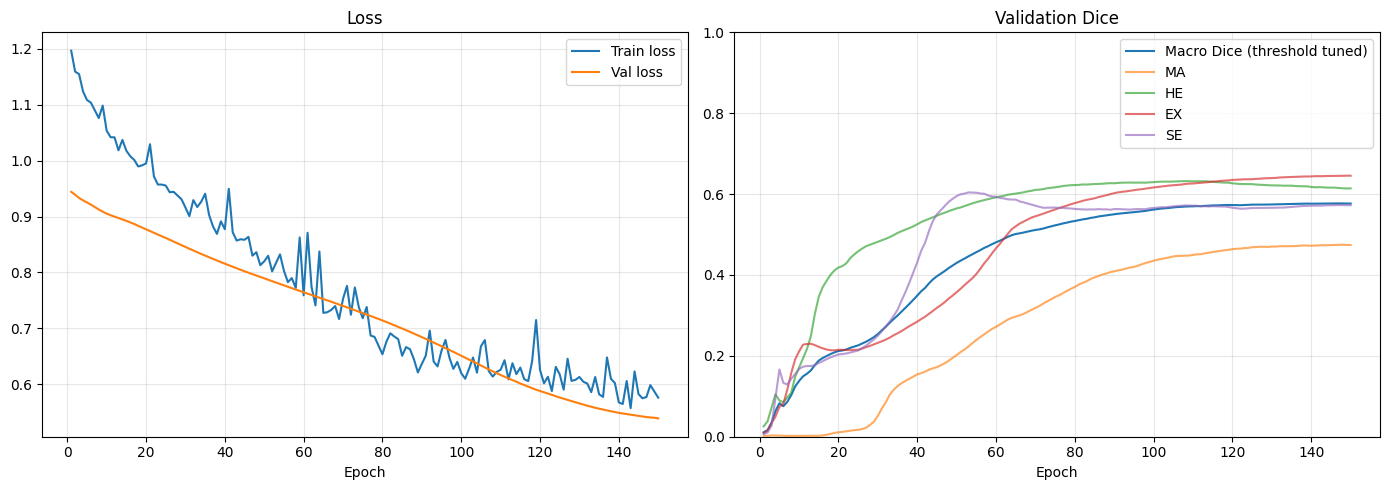

In [14]:
# ============================================================
# 14. Plot learning curves
# ============================================================
hist = pd.DataFrame(history)
display(hist.tail())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(hist['epoch'], hist['train_loss'], label='Train loss')
ax[0].plot(hist['epoch'], hist['val_loss'], label='Val loss')
ax[0].set_title('Loss')
ax[0].set_xlabel('Epoch')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(hist['epoch'], hist['macro_dice_tuned'], label='Macro Dice (threshold tuned)')
for c in CLASS_NAMES:
    ax[1].plot(hist['epoch'], hist[f'{c}_dice_tuned'], alpha=0.65, label=c)
ax[1].set_title('Validation Dice')
ax[1].set_xlabel('Epoch')
ax[1].set_ylim(0, 1)
ax[1].grid(alpha=0.3)
ax[1].legend()
plt.tight_layout()
plt.show()


In [15]:
# ============================================================
# 15. Build top-K averaged model and choose best vs averaged using validation TTA
# ============================================================
def load_model_from_state(state_dict):
    m = DenseNet121AttentionUNet(NUM_CLASSES, pretrained=False).to(DEVICE)
    m.load_state_dict(state_dict)
    m.eval()
    m.freeze_encoder_batchnorm()
    return m


def average_topk_checkpoints(topk_items):
    paths = [p for _, p in topk_items]
    if not paths:
        return None

    avg = None
    n = 0
    for p in paths:
        ck = torch.load(p, map_location='cpu')
        sd = ck['model_state_dict']
        if avg is None:
            avg = {k: v.clone().float() if torch.is_floating_point(v) else v.clone()
                   for k, v in sd.items()}
        else:
            for k, v in sd.items():
                if torch.is_floating_point(v):
                    avg[k] += v.float()
        n += 1

    for k in avg:
        if torch.is_floating_point(avg[k]):
            avg[k] /= float(n)
    return avg


best_ckpt = torch.load(BEST_CKPT, map_location='cpu')
best_single_model = load_model_from_state(best_ckpt['model_state_dict'])

avg_state = average_topk_checkpoints(topk)
if avg_state is not None:
    torch.save({'model_state_dict': avg_state, 'source': 'topk_average', 'topk': [(s, str(p)) for s, p in topk]}, AVERAGED_CKPT)
    averaged_model = load_model_from_state(avg_state)
else:
    averaged_model = None

# Final model comparison uses 4-way TTA and the fine threshold grid.
single_loss, single_metrics = validate_threshold_grid(
    best_single_model, val_loader, criterion, FINAL_THRESHOLD_GRID, tta=True
)
print(f'Best single EMA + TTA validation macro Dice: {single_metrics["macro_dice"]:.5f}')

if averaged_model is not None:
    avg_loss, avg_metrics = validate_threshold_grid(
        averaged_model, val_loader, criterion, FINAL_THRESHOLD_GRID, tta=True
    )
    print(f'Top-{len(topk)} averaged + TTA validation macro Dice: {avg_metrics["macro_dice"]:.5f}')
else:
    avg_metrics = None

if avg_metrics is not None and avg_metrics['macro_dice'] > single_metrics['macro_dice']:
    best_model = averaged_model
    final_val_metrics = avg_metrics
    MODEL_SOURCE = f'top{len(topk)}_checkpoint_average'
else:
    best_model = best_single_model
    final_val_metrics = single_metrics
    MODEL_SOURCE = 'best_single_ema'

best_thresholds = final_val_metrics['thresholds']
print('\nSelected model source:', MODEL_SOURCE)
print('Final validation macro Dice:', final_val_metrics['macro_dice'])
print('Selected thresholds:', dict(zip(CLASS_NAMES, [float(x) for x in best_thresholds])))

threshold_df = pd.DataFrame({
    'class': CLASS_NAMES,
    'name': [CLASS_FULL_NAMES[c] for c in CLASS_NAMES],
    'best_threshold': best_thresholds,
    'val_dice_at_best_threshold_with_tta': final_val_metrics['dice'],
})
display(threshold_df)

with open(THRESHOLD_JSON, 'w') as f:
    json.dump({c: float(t) for c, t in zip(CLASS_NAMES, best_thresholds)}, f, indent=2)


Best single EMA + TTA validation macro Dice: 0.57835
Top-5 averaged + TTA validation macro Dice: 0.57897

Selected model source: top5_checkpoint_average
Final validation macro Dice: 0.5789698443309048
Selected thresholds: {'MA': 0.699999988079071, 'HE': 0.25, 'EX': 0.925000011920929, 'SE': 0.15000000596046448}


,class,name,best_threshold,val_dice_at_best_threshold_with_tta
0,MA,Microaneurysms,0.700,0.465894
1,HE,Haemorrhages,0.250,0.620033
2,EX,Hard Exudates,0.925,0.648468
3,SE,Soft Exudates,0.150,0.581485


In [16]:
# ============================================================
# 16. Final validation metrics with selected thresholds + 4-way TTA
# ============================================================
val_loss_tuned, val_metrics_tuned = validate_fixed_thresholds(
    best_model, val_loader, criterion, best_thresholds, tta=True
)
val_table = pd.DataFrame({
    'class': CLASS_NAMES,
    'name': [CLASS_FULL_NAMES[c] for c in CLASS_NAMES],
    'threshold': best_thresholds,
    'dice': val_metrics_tuned['dice'],
    'iou': val_metrics_tuned['iou'],
    'sensitivity': val_metrics_tuned['sensitivity'],
    'specificity': val_metrics_tuned['specificity'],
    'precision': val_metrics_tuned['precision'],
})
display(val_table)
print('Validation macro Dice:', val_metrics_tuned['macro_dice'])
print('Validation macro IoU :', val_metrics_tuned['macro_iou'])


,class,name,threshold,dice,iou,sensitivity,specificity,precision
0,MA,Microaneurysms,0.700,0.465894,0.303691,0.480241,0.999388,0.452379
1,HE,Haemorrhages,0.250,0.620033,0.449310,0.666520,0.994852,0.579608
2,EX,Hard Exudates,0.925,0.648468,0.479802,0.667952,0.998856,0.630088
3,SE,Soft Exudates,0.150,0.581485,0.409925,0.684347,0.998450,0.505504


Validation macro Dice: 0.5789698443309048
Validation macro IoU : 0.410681913573017


In [17]:
# ============================================================
# 17. Official test-set evaluation with frozen thresholds + 4-way TTA
# ============================================================
if test_loader is None or len(test_ds) == 0:
    print('No official test images were detected.')
else:
    labeled_test_records = [r for r in test_records if r['has_any_mask']]
    if len(labeled_test_records) == 0:
        print('Official test images were found, but no test ground-truth masks were detected. Skipping test metrics.')
    else:
        labeled_test_ds = IDRiDSegmentationDataset(labeled_test_records, IMG_SIZE, train=False)
        labeled_test_loader = DataLoader(labeled_test_ds, shuffle=False, drop_last=False, **loader_kwargs)
        test_loss, test_metrics = validate_fixed_thresholds(
            best_model, labeled_test_loader, criterion, best_thresholds, tta=True
        )

        test_table = pd.DataFrame({
            'class': CLASS_NAMES,
            'name': [CLASS_FULL_NAMES[c] for c in CLASS_NAMES],
            'threshold': best_thresholds,
            'dice': test_metrics['dice'],
            'iou': test_metrics['iou'],
            'sensitivity': test_metrics['sensitivity'],
            'specificity': test_metrics['specificity'],
            'precision': test_metrics['precision'],
        })
        display(test_table)
        print('TEST macro Dice:', test_metrics['macro_dice'])
        print('TEST macro IoU :', test_metrics['macro_iou'])
        test_table.to_csv(TEST_METRICS_CSV, index=False)


,class,name,threshold,dice,iou,sensitivity,specificity,precision
0,MA,Microaneurysms,0.700,0.423552,0.268675,0.504167,0.999194,0.365164
1,HE,Haemorrhages,0.250,0.635482,0.465719,0.774951,0.993297,0.538557
2,EX,Hard Exudates,0.925,0.746638,0.595708,0.758267,0.997295,0.735360
3,SE,Soft Exudates,0.150,0.706758,0.546501,0.870671,0.999000,0.594784


TEST macro Dice: 0.6281075489736553
TEST macro IoU : 0.4691508057703952


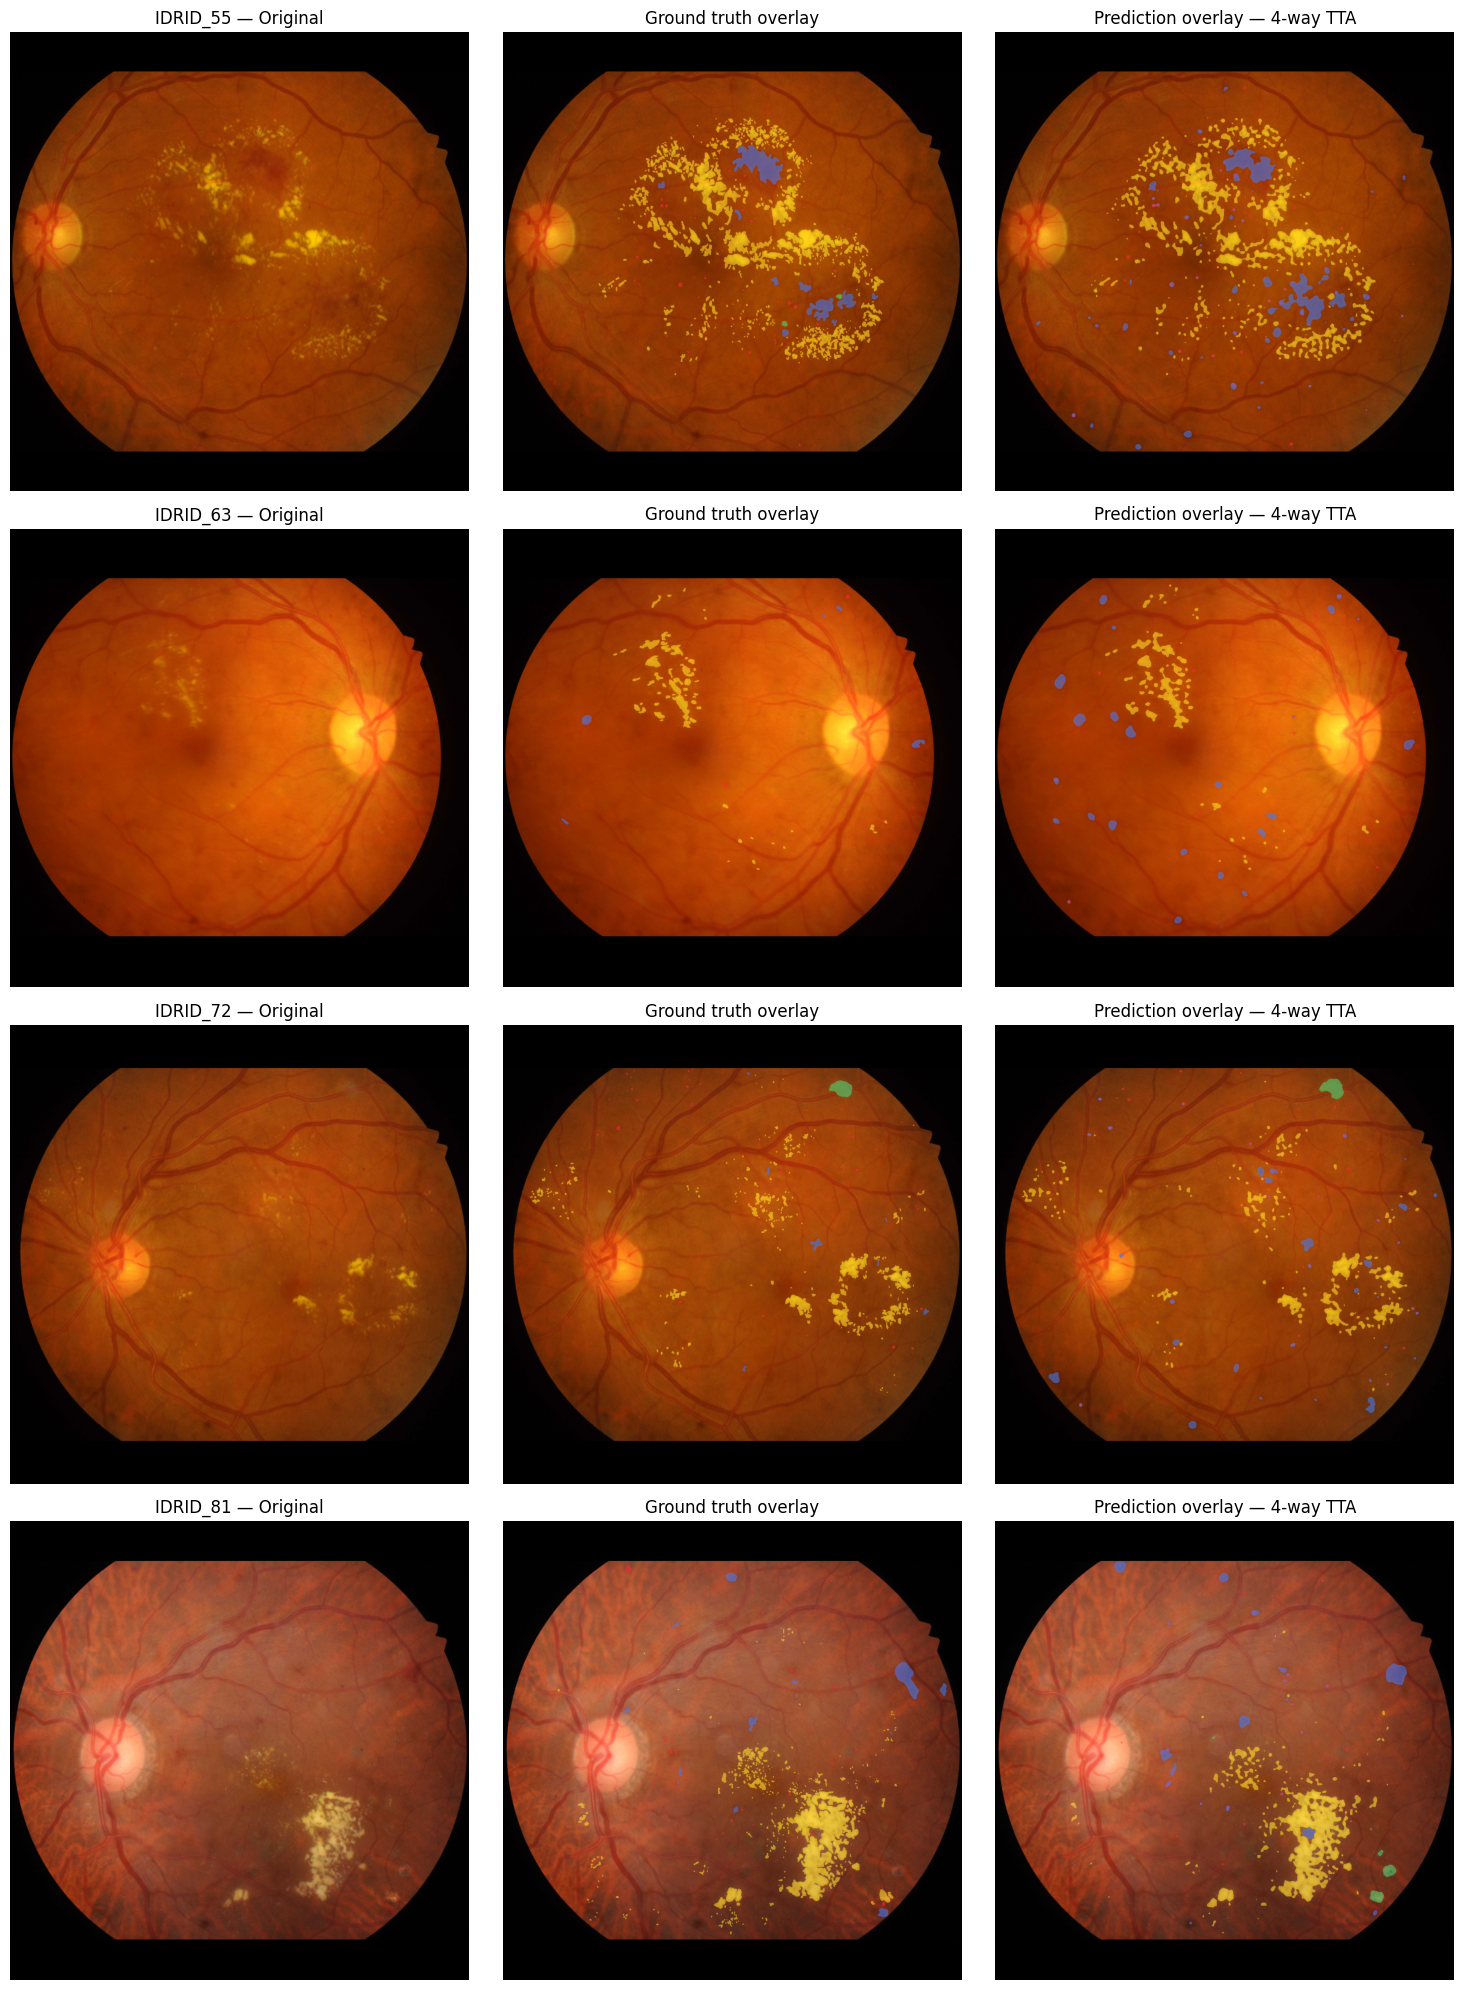

Overlay legend: {'MA': 'Microaneurysms', 'HE': 'Haemorrhages', 'EX': 'Hard Exudates', 'SE': 'Soft Exudates'}


In [18]:
# ============================================================
# 18. Visualize TTA predictions
# ============================================================
LESION_COLORS = {
    'MA': np.array([255, 50, 50], dtype=np.float32),
    'HE': np.array([70, 130, 255], dtype=np.float32),
    'EX': np.array([255, 220, 40], dtype=np.float32),
    'SE': np.array([70, 220, 120], dtype=np.float32),
}


def denormalize_image(t):
    x = t.detach().cpu().numpy().transpose(1, 2, 0)
    x = x * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(x, 0, 1)


def overlay_masks(image01, masks, alpha=0.55):
    out = (image01 * 255.0).astype(np.float32)
    for ci, c in enumerate(CLASS_NAMES):
        region = masks[ci] > 0.5
        if region.any():
            out[region] = (1 - alpha) * out[region] + alpha * LESION_COLORS[c]
    return np.clip(out / 255.0, 0, 1)


viz_ds = test_ds if (test_ds is not None and len(test_ds) > 0) else val_ds
n_show = min(4, len(viz_ds))
indices = np.linspace(0, len(viz_ds)-1, n_show, dtype=int)

fig, axes = plt.subplots(n_show, 3, figsize=(15, 5*n_show))
if n_show == 1:
    axes = np.expand_dims(axes, axis=0)

best_model.eval()
for row, idx in enumerate(indices):
    sample = viz_ds[idx]
    image_t = sample['image']
    mask_t = sample['mask']
    image = denormalize_image(image_t)

    with torch.no_grad(), torch.cuda.amp.autocast(enabled=AMP):
        probs = predict_probs(best_model, image_t.unsqueeze(0).to(DEVICE), tta=True)[0].cpu().numpy()
    pred = probs >= best_thresholds[:, None, None]

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"{sample['id']} — Original")
    axes[row, 1].imshow(overlay_masks(image, mask_t.numpy()))
    axes[row, 1].set_title('Ground truth overlay')
    axes[row, 2].imshow(overlay_masks(image, pred.astype(np.float32)))
    axes[row, 2].set_title('Prediction overlay — 4-way TTA')
    for col in range(3):
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()
print('Overlay legend:', {c: CLASS_FULL_NAMES[c] for c in CLASS_NAMES})


In [19]:
# ============================================================
# 19. Save final maximum-quality deployment/training bundle
# ============================================================
final_bundle = {
    'architecture': 'DenseNet121AttentionUNet_scSE_DeepSupervision',
    'model_state_dict': best_model.state_dict(),
    'model_source': MODEL_SOURCE,
    'class_names': CLASS_NAMES,
    'class_full_names': CLASS_FULL_NAMES,
    'thresholds': {c: float(t) for c, t in zip(CLASS_NAMES, best_thresholds)},
    'input_size': IMG_SIZE,
    'tta': 'identity+hflip+vflip+hvflip recommended for maximum-quality inference',
    'normalization': {
        'mean': IMAGENET_MEAN.tolist(),
        'std': IMAGENET_STD.tolist(),
    },
    'config': CONFIG,
    'best_single_checkpoint_epoch': int(best_ckpt['epoch']),
    'final_val_macro_dice_tta': float(val_metrics_tuned['macro_dice']),
}
torch.save(final_bundle, FINAL_BUNDLE)

print('Saved files:')
for p in [BEST_CKPT, AVERAGED_CKPT, FINAL_BUNDLE, HISTORY_CSV, THRESHOLD_JSON, TEST_METRICS_CSV]:
    if p.exists():
        print(f'  {p}  ({p.stat().st_size / (1024**2):.2f} MB)')

print('\nMAIN WEIGHT BUNDLE TO DOWNLOAD/USE LATER:')
print(FINAL_BUNDLE)


Saved files:
  /kaggle/working/idrid_densenet121_attention_unet_best.pth  (87.06 MB)
  /kaggle/working/idrid_densenet121_attention_unet_topk_avg.pth  (87.03 MB)
  /kaggle/working/idrid_densenet121_attention_unet_maxquality_bundle.pth  (87.07 MB)
  /kaggle/working/idrid_training_history_maxquality.csv  (0.03 MB)
  /kaggle/working/idrid_thresholds_maxquality.json  (0.00 MB)
  /kaggle/working/idrid_test_metrics_maxquality.csv  (0.00 MB)

MAIN WEIGHT BUNDLE TO DOWNLOAD/USE LATER:
/kaggle/working/idrid_densenet121_attention_unet_maxquality_bundle.pth


## Final model output and recommended use

For each fundus image the model produces four segmentation channels:

```text
0 → MA  Microaneurysms
1 → HE  Haemorrhages
2 → EX  Hard Exudates
3 → SE  Soft Exudates
```

For **maximum-quality inference**, use the four-way flip TTA implemented in the notebook and apply each lesion's own validation-tuned threshold.

### Main output files

- `idrid_densenet121_attention_unet_best.pth` — best single EMA checkpoint.
- `idrid_densenet121_attention_unet_topk_avg.pth` — average of the strongest validation checkpoints.
- `idrid_densenet121_attention_unet_maxquality_bundle.pth` — **final automatically selected model for app/inference use**.
- `idrid_training_history_maxquality.csv` — long-run training history.
- `idrid_thresholds_maxquality.json` — final per-lesion thresholds.
- `idrid_test_metrics_maxquality.csv` — official test results when masks are available.

The notebook compares the single best EMA checkpoint against the top-K averaged model and keeps whichever performs better on the validation set with TTA. Test data remains untouched until the final evaluation.
